In [2]:
!pip install mplsoccer
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Arc
import seaborn as sns
import mplsoccer as ms
from mplsoccer import Pitch, Sbopen, VerticalPitch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.4/86.4 kB 2.3 MB/s eta 0:00:00


In [3]:
parser = Sbopen()

seasons = [27]

all_events = []

for season_id in seasons:
    df_matches = parser.match(competition_id = 11, season_id = season_id)
    for match_id in df_matches.match_id.unique():
        df_event = parser.event(match_id)[0]  # [0] = event dataframe
        df_event['match_id'] = match_id
        all_events.append(df_event)

df = pd.concat(all_events, ignore_index=True)

phase 1: creating a dataframe with each player's KPIs for every match they've played

In [4]:
shots = df[df['type_name'] == 'Shot'].copy()
passes = df[df['type_name'] == 'Pass'].copy()
dribbles = df[df['type_name'] == 'Dribble'].copy()
carries = df[df['type_name'] == 'Carry'].copy()

In [5]:
FINAL_THIRD_X = 66.6

In [6]:
# shots and average xG
shots_features = (
    shots.groupby(['match_id', 'player_id', 'player_name'], as_index=False)
         .agg(
             shots_total=('id', 'count'),
             avg_xg=('shot_statsbomb_xg', 'mean')))

In [7]:
# position for each player
player_positions = df[['player_id', 'player_name', 'position_name']].drop_duplicates(subset='player_id')

In [8]:
# passes and ball receipts in final third
passes_final_third = passes[passes['end_x'] > FINAL_THIRD_X]

ball_receipts_final_third = (
    passes_final_third.groupby(['match_id', 'pass_recipient_id', 'pass_recipient_name'], as_index=False)
                      .size()
                      .rename(columns={
                          'pass_recipient_id': 'player_id',
                          'pass_recipient_name': 'player_name',
                          'size': 'ball_receipts_final_third'}))

In [9]:
# carries and dribbles
carries_features = (
    carries.groupby(['match_id', 'player_id', 'player_name'], as_index=False)
           .size()
           .rename(columns={'size': 'carries_total'}))

dribbles_features = (
    dribbles.groupby(['match_id', 'player_id', 'player_name'], as_index=False)
            .size()
            .rename(columns={'size': 'dribbles_total'}))

In [10]:
# number of minutes played in each game
minutes_played = (
    df.groupby(['match_id', 'player_id', 'player_name'], as_index=False)
      .agg(minutes_played=('minute', 'max')))

# total minutes played in the league
player_minutes_total = (
    df.groupby(['match_id', 'player_id', 'player_name'], as_index=False)
      .agg(minutes_played=('minute', 'max'))
      .groupby(['player_id', 'player_name'], as_index=False)
      .agg(total_minutes=('minutes_played', 'sum')))

In [11]:
# filtering players who have played atleast 5 full games (90 x 5 = 450 minutes)
eligible_players = player_minutes_total.query("total_minutes > 450")[['player_id']]

In [12]:
# merging all feature dataframes together
from functools import reduce

dfs_to_merge = [
    shots_features,
    ball_receipts_final_third,
    carries_features,
    dribbles_features,
    minutes_played]

# merging all on match_id, player_id
player_match_df = reduce(
    lambda left, right: pd.merge(left, right, on=['match_id', 'player_id', 'player_name'], how='outer'),
    dfs_to_merge)

In [13]:
player_match_df = player_match_df.merge(eligible_players, on='player_id', how='inner')
player_match_df.fillna(0, inplace=True)

In [14]:
player_match_df = player_match_df.merge(
    player_positions[['player_id', 'position_name']],
    on='player_id',
    how='left')

In [15]:
# getting each player's team in each match to classify home and away games
player_teams = (
    df[['match_id', 'player_id', 'player_name', 'team_name']]
      .drop_duplicates())

# merging team info into player_match_df
player_match_df = player_match_df.merge(player_teams, on=['match_id', 'player_id', 'player_name'], how='left')

In [16]:
# extracting match_id, home_team, and away_team
match_info = df_matches[['match_id', 'home_team_name', 'away_team_name']]

# merging into player_match_df
player_match_df = player_match_df.merge(match_info, on='match_id', how='left')

In [17]:
# adding the home/away column
player_match_df['home_away'] = np.where(
    player_match_df['team_name'] == player_match_df['home_team_name'],
    'home',
    'away')

In [18]:
# adding the target variable: whether a player scored or not (0/1)

# creating a 'is_goal' column in the shots df
shots['is_goal'] = (shots['outcome_name'] == 'Goal').astype(int)

# aggregating per player per match
player_goals = (
    shots.groupby(['match_id', 'player_id', 'player_name'], as_index=False)
         .agg(goals=('is_goal', 'sum'))
)

# converting to binary: 1 if player scored, 0 otherwise
player_goals['scored'] = (player_goals['goals'] > 0).astype(int)
player_goals.drop(columns='goals', inplace=True)

# merging into player_match_df

player_match_df = player_match_df.merge(
    player_goals, on=['match_id', 'player_id', 'player_name'], how='left')

# Fill NaNs with 0 (players with no goals in the match)
player_match_df['scored'] = player_match_df['scored'].fillna(0).astype(int)

phase 2: computing rolling 5-match averages, the model will predict probability of scoring using data from the previous 5 games

In [39]:
# ordering chronologically by player and match
player_match_df['match_date'] = df_matches['match_date']
player_match_df = player_match_df.sort_values(['match_date']).reset_index(drop=True)

In [42]:
player_match_df.head(25)

,match_id,player_id,player_name,shots_total,avg_xg,ball_receipts_final_third,carries_total,dribbles_total,minutes_played,position_name,...,away_team_name,home_away,scored,match_date,avg_xg_rolling_5,shots_total_rolling_5,minutes_played_rolling_5,carries_total_rolling_5,dribbles_total_rolling_5,ball_receipts_final_third_rolling_5
0,266160,23843.0,Diego Mariño Villar,0.0,0.000000,0.0,9.0,0.0,91,Goalkeeper,...,Barcelona,home,0,2015-08-21,NaN,NaN,NaN,NaN,NaN,NaN
1,266424,5695.0,James David Rodríguez Rubio,2.0,0.042976,22.0,26.0,2.0,54,Right Wing,...,Barcelona,home,0,2015-08-22,NaN,NaN,NaN,NaN,NaN,NaN
2,266424,5503.0,Lionel Andrés Messi Cuccittini,2.0,0.075841,27.0,32.0,3.0,91,Right Wing,...,Barcelona,away,0,2015-08-22,0.151211,3.2,90.4,55.6,8.6,49.6
3,266424,5485.0,Raphaël Varane,1.0,0.389242,2.0,26.0,0.0,91,Left Center Back,...,Barcelona,home,0,2015-08-22,NaN,NaN,NaN,NaN,NaN,NaN
4,266424,5721.0,Daniel Carvajal Ramos,1.0,0.047860,9.0,11.0,1.0,88,Right Back,...,Barcelona,home,0,2015-08-22,NaN,NaN,NaN,NaN,NaN,NaN
5,266424,5552.0,Marcelo Vieira da Silva Júnior,1.0,0.096657,13.0,25.0,1.0,58,Left Back,...,Barcelona,home,0,2015-08-23,NaN,NaN,NaN,NaN,NaN,NaN
6,266424,5506.0,Javier Alejandro Mascherano,0.0,0.000000,0.0,15.0,0.0,27,Center Defensive Midfield,...,Barcelona,away,0,2015-08-23,0.000000,0.0,89.8,56.0,0.4,2.4
7,266424,5574.0,Toni Kroos,0.0,0.000000,23.0,48.0,0.0,90,Left Center Midfield,...,Barcelona,home,0,2015-08-23,NaN,NaN,NaN,NaN,NaN,NaN
8,266467,6724.0,Manuel Agudo Durán,4.0,0.098037,47.0,47.0,8.0,88,Left Wing,...,Barcelona,home,1,2015-08-23,NaN,NaN,NaN,NaN,NaN,NaN
9,266160,24149.0,José Antonio García Rabasco,1.0,0.066575,15.0,22.0,0.0,75,Center Defensive Midfield,...,Barcelona,home,0,2015-08-24,NaN,NaN,NaN,NaN,NaN,NaN


In [43]:
rolling_features = [
    'avg_xg',
    'shots_total',
    'minutes_played',
    'carries_total',
    'dribbles_total',
    'ball_receipts_final_third']

In [44]:
for col in rolling_features:
    player_match_df[f'{col}_rolling_5'] = (
        player_match_df.groupby('player_id')[col]
                       .transform(lambda x: x.rolling(5, min_periods=1).mean().shift(1)))
                       # .shift(1) ensures the rolling average for the nth match only includes matches n-1, n-2, n-3,... and not the nth match itself

phase 3: preparing the dataframe for the model

In [45]:
final_features = [
    'avg_xg_rolling_5',
    'shots_total_rolling_5',
    'minutes_played_rolling_5',
    'carries_total_rolling_5',
    'dribbles_total_rolling_5',
    'ball_receipts_final_third_rolling_5']

core_columns = [
    'match_id',
    'player_id',
    'player_name',
    'team_name',
    'home_away',
    'position_name',
    'scored']

# keeping only relevant columns
model_df = player_match_df[core_columns + final_features].copy()

In [46]:
# one-hot encoding home/away
model_df = pd.get_dummies(model_df, columns=['home_away', 'position_name'], drop_first=True)

In [47]:
model_df.fillna(0, inplace=True)

phase 4: building the models

In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, log_loss, brier_score_loss

In [49]:
#first 70% matches for training, last 30% for testing
train_size = int(0.7 * len(model_df))
train_df = model_df.iloc[:train_size]
test_df  = model_df.iloc[train_size:]

X_train = train_df.drop(columns=['match_id', 'player_id', 'player_name', 'team_name', 'scored'])
y_train = train_df['scored']

X_test = test_df.drop(columns=['match_id', 'player_id', 'player_name', 'team_name', 'scored'])
y_test = test_df['scored']

In [50]:
# baseline model: logistic regression
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(class_weight = 'balanced', max_iter = 1000, random_state = 14))])

In [51]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=14))])

In [52]:
# predicting probabilities for the positive class
y_pred_proba = pipeline.predict_proba(X_test)[:, 1]

# metrics
roc_auc = roc_auc_score(y_test, y_pred_proba)
logloss = log_loss(y_test, y_pred_proba)
brier = brier_score_loss(y_test, y_pred_proba)

print(f'ROC-AUC: {roc_auc:.3f}')
print(f'Log-loss: {logloss:.3f}')
print(f'Brier score: {brier:.3f}')

ROC-AUC: 0.782
Log-loss: 0.538
Brier score: 0.182


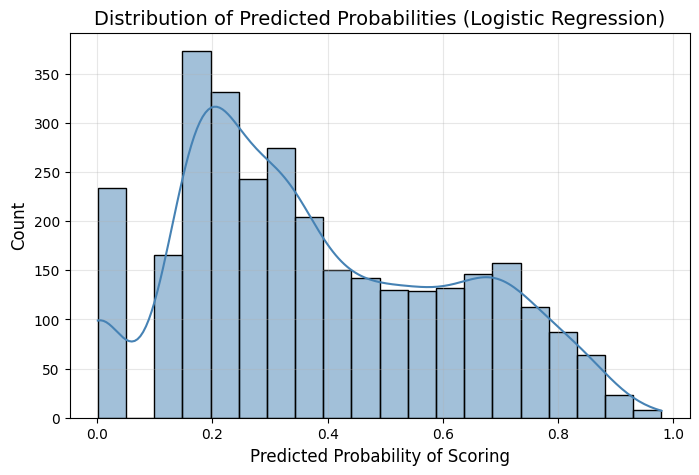

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get predicted probabilities on test set
y_pred_proba_lr = pipeline.predict_proba(X_test)[:, 1]

# Plot histogram + KDE
plt.figure(figsize=(8, 5))
sns.histplot(y_pred_proba_lr, bins=20, kde=True, color='steelblue', edgecolor='black')

plt.title('Distribution of Predicted Probabilities (Logistic Regression)', fontsize=14)
plt.xlabel('Predicted Probability of Scoring', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.grid(alpha=0.3)
plt.show()

In [54]:
# gradient boosting

from xgboost import XGBClassifier

# calculating imbalance ratio
ratio = y_train.value_counts()[0] / y_train.value_counts()[1]

xgb_model = XGBClassifier(
    n_estimators = 300,
    max_depth = 5,
    learning_rate = 0.2,
    scale_pos_weight = ratio,  # handle imbalance
    use_label_encoder = False,
    random_state = 14)

In [55]:
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.2, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

In [56]:
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_pred_proba)
logloss = log_loss(y_test, y_pred_proba)
brier = brier_score_loss(y_test, y_pred_proba)

print(f'XGBoost ROC-AUC: {roc_auc:.3f}')
print(f'XGBoost Log-loss: {logloss:.3f}')
print(f'XGBoost Brier score: {brier:.3f}')

XGBoost ROC-AUC: 0.702
XGBoost Log-loss: 0.355
XGBoost Brier score: 0.100


In [57]:
# testing raw xg

X_train_xg = train_df[['avg_xg_rolling_5']].copy()
y_train = train_df['scored']

X_test_xg = test_df[['avg_xg_rolling_5']].copy()
y_test = test_df['scored']

# fitting logistic regression on just xG

lr_xg = LogisticRegression(class_weight = 'balanced', max_iter = 1000, random_state = 42)
lr_xg.fit(X_train_xg, y_train)

# predicting probabilities
y_train_pred = lr_xg.predict_proba(X_train_xg)[:,1]
y_test_pred = lr_xg.predict_proba(X_test_xg)[:,1]

print("Raw xG ROC-AUC (test):", roc_auc_score(y_test, y_test_pred))
print("Raw xG Log-loss (test):", log_loss(y_test, y_test_pred))
print("Raw xG Brier score (test):", brier_score_loss(y_test, y_test_pred))

Raw xG ROC-AUC (test): 0.7369480038123477
Raw xG Log-loss (test): 0.6349037170034023
Raw xG Brier score (test): 0.2163268278426775


In [58]:
import pickle

# Assuming your trained model variable is called 'log_reg_model'
with open('goal_prediction_logreg.pkl', 'wb') as f:
    pickle.dump(pipeline, f)

In [59]:
from google.colab import files
files.download('goal_prediction_logreg.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>